## Group Members:

##### 1) Muhammad Afiq Danish bin Mohd Hazni (A23CS0118)
##### 2) Muhammad Adam bin Razali (A23CS0116)
##### 3) Muhammad Naim bin Abdullah (A230134)



# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [3]:
#Write your code here
import pandas as pd

#Load the dataset
with open ('Rainfall.csv', 'r') as file:
    lines = [line.replace('"', ' ') for line in file]

with open ('CleanedRainfall.csv', 'w') as cFile:
    cFile.writelines(lines)

rainfall = pd.read_csv("CleanedRainfall.csv")
rainfall.columns = rainfall.columns.str.strip()

# Display first 5 rows
print(rainfall.head())

# Check and handle for any missing values
print(rainfall.isna().sum())
rainfall.dropna(inplace=True)

#Summary statistics for all numeric columns
print(rainfall.describe())

   Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
0   North  2023   Jan  StationA         56.2          9       12.1        2.5   
1   North  2023   Feb  StationA         72.1         12       14.7        3.0   
2   North  2023   Jan  StationB         60.5         10       11.2        1.8   
3   South  2023   Jan  StationC         81.0         13       19.6        7.2   
4   South  2023   Feb  StationC         63.4         11       20.1        7.7   

  UrbanRural  
0     Urban   
1     Urban   
2     Rural   
3     Urban   
4     Urban   
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64
         Year  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
count    10.0    10.000000   10.00000  10.000000  10.000000
mean   2023.0    66.160000   10.90000  16.100000   4.740000
std       0.0    12.154121    1.66333   2.982542   2.029888
min    2023.0    

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [4]:
#Write your code here
total_rainfall = rainfall.groupby('Station')['Rainfall_mm'].sum()
print(total_rainfall)

avg_rainyDays = rainfall.groupby('Station')['RainyDays'].mean()
print(avg_rainyDays)

avg_maxTemp = rainfall.groupby('Station')['MaxTemp_C'].mean()
print(avg_maxTemp)

avg_minTemp = rainfall.groupby('Station')['MinTemp_C'].mean()
print(avg_minTemp)


Station
StationA    128.3
StationB    122.0
StationC    144.4
StationD    105.3
StationE    161.6
Name: Rainfall_mm, dtype: float64
Station
StationA    10.5
StationB    10.5
StationC    12.0
StationD     9.0
StationE    12.5
Name: RainyDays, dtype: float64
Station
StationA    13.40
StationB    13.10
StationC    19.85
StationD    16.65
StationE    17.50
Name: MaxTemp_C, dtype: float64
Station
StationA    2.75
StationB    2.50
StationC    7.45
StationD    5.90
StationE    5.10
Name: MinTemp_C, dtype: float64


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [5]:
#Write your code here
grouped = rainfall.groupby(['Region', 'UrbanRural'])

avgRainfall = grouped['Rainfall_mm'].mean()
avgMaxTemp = grouped['MaxTemp_C'].mean()
avgRD = grouped['RainyDays'].mean()

print(avgRainfall)
print(avgMaxTemp)
print(avgRD)


Region  UrbanRural
East    Rural         52.65
North   Rural         61.00
        Urban         64.15
South   Urban         72.20
West    Urban         80.80
Name: Rainfall_mm, dtype: float64
Region  UrbanRural
East    Rural         16.65
North   Rural         13.10
        Urban         13.40
South   Urban         19.85
West    Urban         17.50
Name: MaxTemp_C, dtype: float64
Region  UrbanRural
East    Rural          9.0
North   Rural         10.5
        Urban         10.5
South   Urban         12.0
West    Urban         12.5
Name: RainyDays, dtype: float64


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [6]:
#Write your code here
monthRegion = rainfall.groupby(['Month', 'Region'])

totRainfall = monthRegion['Rainfall_mm'].sum()
avgRain = monthRegion['Rainfall_mm'].mean()
minRainfall = monthRegion['Rainfall_mm'].min()
maxRainfall = monthRegion['Rainfall_mm'].max()

print(totRainfall)
print()
print(avgRain)
print()
print(minRainfall)
print()
print(maxRainfall)

Month  Region
Feb    East       59.6
       North      72.1
       South      63.4
       West       84.2
Jan    East       45.7
       North     116.7
       South      81.0
       West       77.4
Mar    North      61.5
Name: Rainfall_mm, dtype: float64

Month  Region
Feb    East      59.60
       North     72.10
       South     63.40
       West      84.20
Jan    East      45.70
       North     58.35
       South     81.00
       West      77.40
Mar    North     61.50
Name: Rainfall_mm, dtype: float64

Month  Region
Feb    East      59.6
       North     72.1
       South     63.4
       West      84.2
Jan    East      45.7
       North     56.2
       South     81.0
       West      77.4
Mar    North     61.5
Name: Rainfall_mm, dtype: float64

Month  Region
Feb    East      59.6
       North     72.1
       South     63.4
       West      84.2
Jan    East      45.7
       North     60.5
       South     81.0
       West      77.4
Mar    North     61.5
Name: Rainfall_mm, dtype: flo

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [7]:
#Write your code here
highestRegion = maxRainfall.idxmax()
highestRegion

('Feb', ' West')

5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [8]:
#Write your code here
yearUrbanRural = rainfall.groupby(['Year', 'UrbanRural'])

averageRain = yearUrbanRural['Rainfall_mm'].mean()
minimum = yearUrbanRural['Rainfall_mm'].min()
maximum = yearUrbanRural['Rainfall_mm'].max()

print(averageRain)
print()
print(minimum)
print()
print(maximum)


Year  UrbanRural
2023  Rural         56.825000
      Urban         72.383333
Name: Rainfall_mm, dtype: float64

Year  UrbanRural
2023  Rural         45.7
      Urban         56.2
Name: Rainfall_mm, dtype: float64

Year  UrbanRural
2023  Rural         61.5
      Urban         84.2
Name: Rainfall_mm, dtype: float64


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [9]:
#Write your code here
gpRM = rainfall.groupby(['Region', 'Month'])

avgTempPerM = gpRM['MaxTemp_C'].mean() - gpRM['MinTemp_C'].mean()
avgTempPerM


Region  Month
East    Feb      11.7
        Jan       9.8
North   Feb      11.7
        Jan       9.5
        Mar      11.8
South   Feb      12.4
        Jan      12.4
West    Feb      12.9
        Jan      11.9
dtype: float64

## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



Region  UrbanRural
East    Rural         105.3
North   Rural         122.0
        Urban         128.3
South   Urban         144.4
West    Urban         161.6
Name: Rainfall_mm, dtype: float64


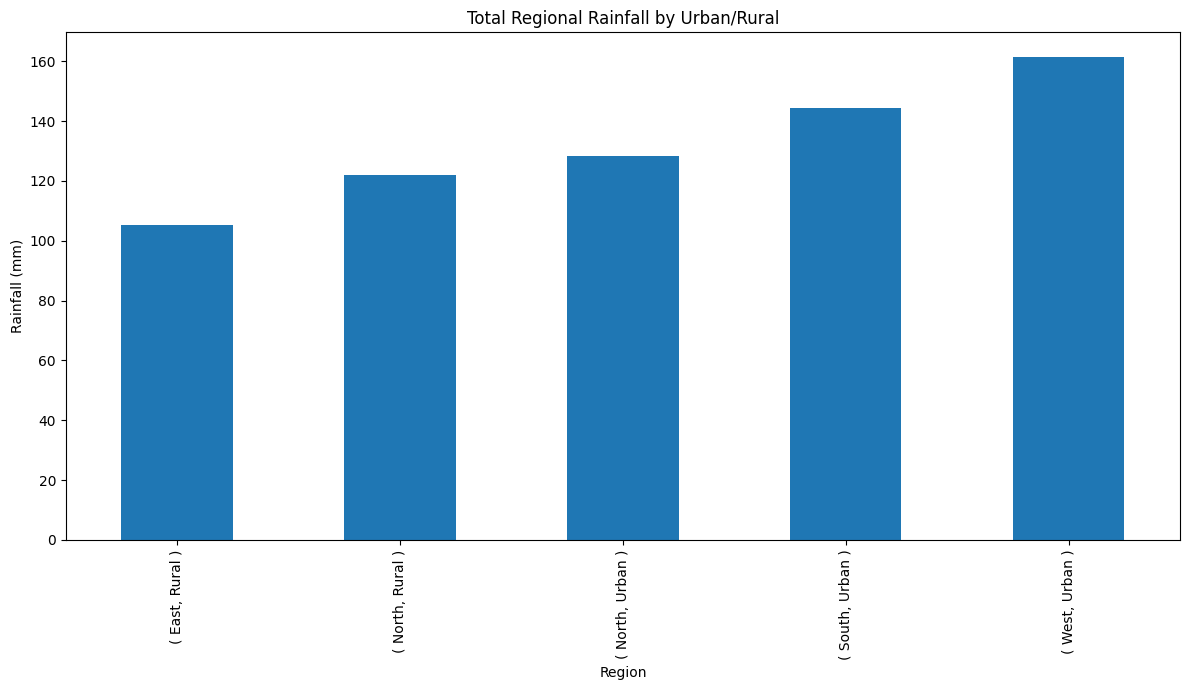

<Figure size 640x480 with 0 Axes>

In [10]:
#Write your code here
import matplotlib.pyplot as plt
import numpy as np

tot_rainfall_region = rainfall.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum()
print(tot_rainfall_region)

plt.figure(figsize = (12, 7))
tot_rainfall_region.plot(kind = 'bar')
plt.title('Total Regional Rainfall by Urban/Rural')
plt.xlabel('Region')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.show()
plt.savefig('Bar_Plot.png')

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



Month  Station 
Feb    StationA    72.1
       StationC    63.4
       StationD    59.6
       StationE    84.2
Jan    StationA    56.2
       StationB    60.5
       StationC    81.0
       StationD    45.7
       StationE    77.4
Mar    StationB    61.5
Name: Rainfall_mm, dtype: float64


<Figure size 1200x700 with 0 Axes>

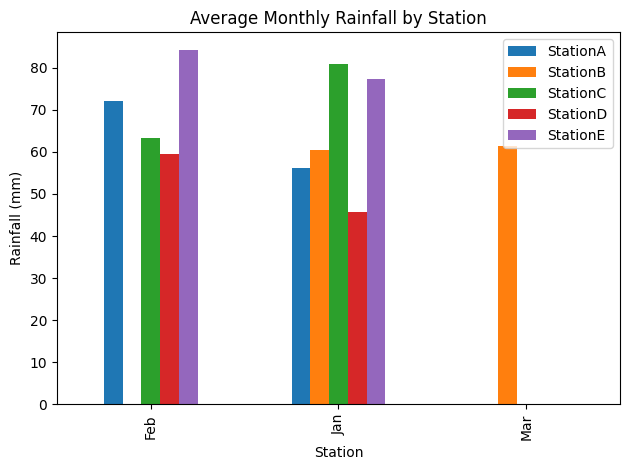

In [11]:
#Write your code here
avg_monthly_rainfall = rainfall.groupby(['Month', 'Station'])['Rainfall_mm'].mean()
print(avg_monthly_rainfall)

plt.figure(figsize = (12,7))
avg_monthly_rainfall.unstack().plot(kind = 'bar', width = .5)
plt.title('Average Monthly Rainfall by Station')
plt.xlabel('Station')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.legend()
plt.show()


3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



Month      Jan    Feb   Mar
Station                    
StationA  56.2  72.10  61.5
StationB  60.5  69.82  61.5
StationC  81.0  63.40  61.5
StationD  45.7  59.60  61.5
StationE  77.4  84.20  61.5


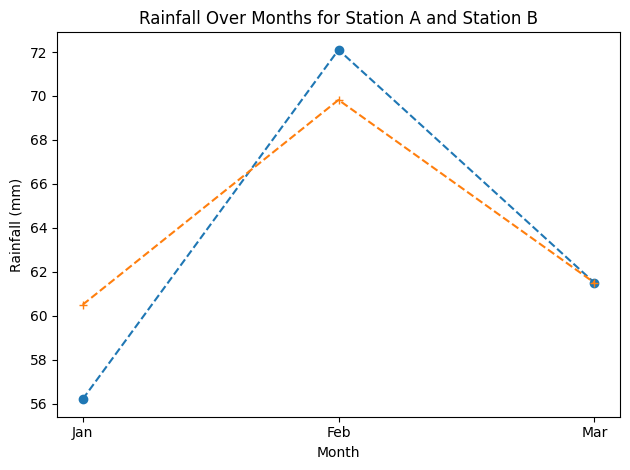

In [18]:
#Write your code here
station = rainfall.set_index(['Station', 'Month'])['Rainfall_mm'].unstack()
station = station.fillna(station.mean().round(2)).reindex(columns=['Jan', 'Feb', 'Mar'])
print(station)


fig, ax = plt.subplots()
ax.plot(station.columns, station.loc['StationA'], marker = 'o', label='StationA', linestyle='--')
ax.plot(station.columns, station.loc['StationB'], marker = '+', label='StationB', linestyle='--')

plt.title('Rainfall Over Months for Station A and Station B')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.savefig('Line_Plot.png')

4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



C:\Users\user\AppData\Local\Temp\ipykernel_12268\3678186147.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_region, labels=rainfall['Region'].unique())


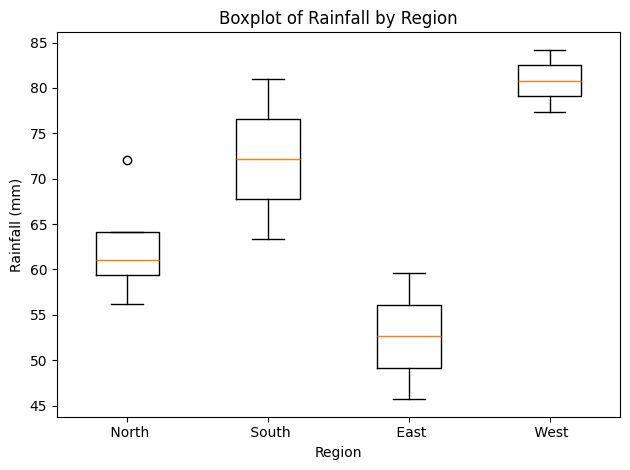

In [184]:
#Write your code here

data_by_region = [rainfall[rainfall['Region'] == region]['Rainfall_mm'] for region in rainfall['Region'].unique()]
data_by_region

fig, ax = plt.subplots()
ax.boxplot(data_by_region, labels=rainfall['Region'].unique())

plt.title('Boxplot of Rainfall by Region')
plt.xlabel('Region')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.savefig('Box_Plot.png')


5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



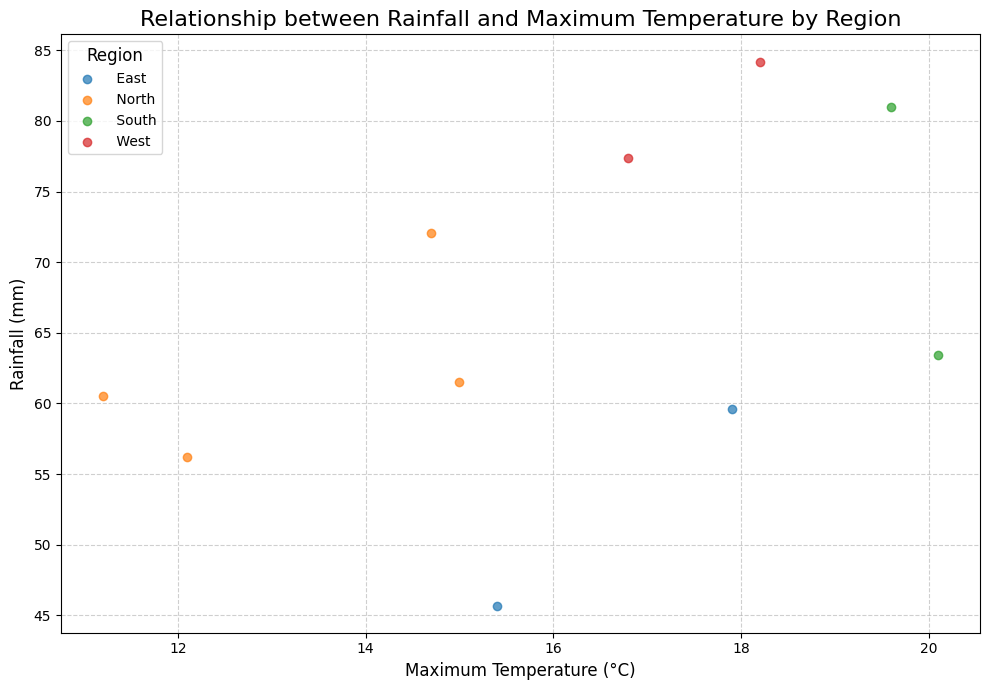

In [194]:
#Write your code here

# Aggregate first to handle duplicates
relationship = rainfall.groupby(['MaxTemp_C', 'Region'])['Rainfall_mm'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each region (column) against the index (MaxTemp_C)
for region in relationship.columns:
    ax.scatter(relationship.index, relationship[region], 
               label=region, alpha=0.7)

plt.title('Relationship between Rainfall and Maximum Temperature by Region', fontsize=16)
plt.xlabel('Maximum Temperature (°C)', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.legend(title='Region', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Scatter_Plot.png')
plt.show()

6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



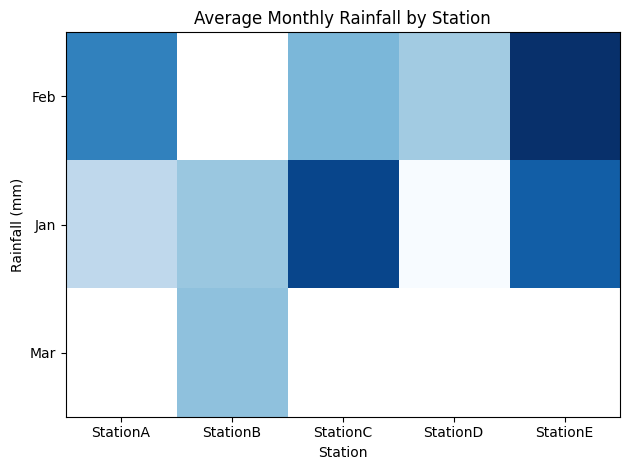

<Figure size 640x480 with 0 Axes>

In [ ]:
#Write your code here

mean_monthly_rainfall = rainfall.groupby(['Month', 'Station'])['Rainfall_mm'].mean().unstack()
mean_monthly_rainfall 

fig, ax = plt.subplots()
ax.imshow(mean_monthly_rainfall, cmap='Blues', aspect='auto')
ax.set_title('Average Monthly Rainfall by Station')
ax.set_xlabel('Station')
ax.set_ylabel('Rainfall (mm)')
ax.set_xticks(range(len(mean_monthly_rainfall.columns)))
ax.set_yticks(range(len(mean_monthly_rainfall.index)))
ax.set_xticklabels(mean_monthly_rainfall.columns)
ax.set_yticklabels(mean_monthly_rainfall.index)
plt.tight_layout()
plt.show()
plt.savefig('Heatmap.png')

7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [177]:
#Write your code here

# done

## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


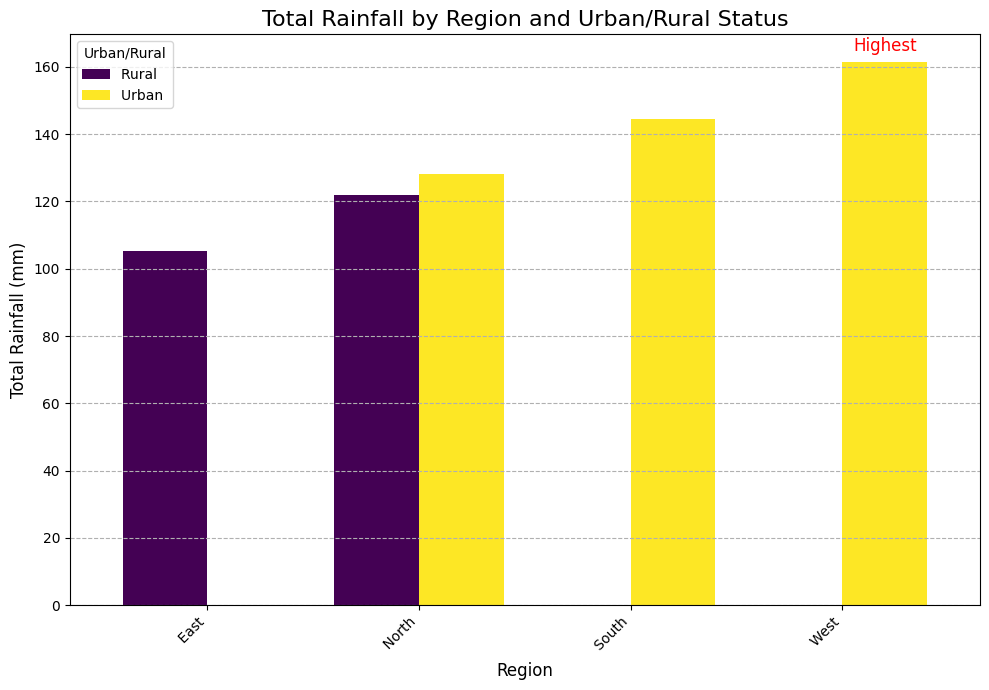

In [178]:
#Write your code here

# Group data by Region and UrbanRural status to get total rainfall
total_rainfall_region = rainfall.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().unstack()

# Create the bar plot
ax = total_rainfall_region.plot(kind='bar', figsize=(10, 7), width=0.8, colormap='viridis')

# --- Annotation ---
# Find the highest value
highest_rainfall = 0
for p in ax.patches:
    height = p.get_height()
    if height > highest_rainfall:
        highest_rainfall = height

# Annotate the highest bar
for p in ax.patches:
    if p.get_height() == highest_rainfall:
        ax.text(p.get_x() + p.get_width() / 2., highest_rainfall + 2, 'Highest', ha='center', va='bottom', fontsize=12, color='red')

# Formatting
plt.title('Total Rainfall by Region and Urban/Rural Status', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Urban/Rural')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')

# Save the figure
plt.savefig('total_rainfall_annotated.png')

plt.show()

2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


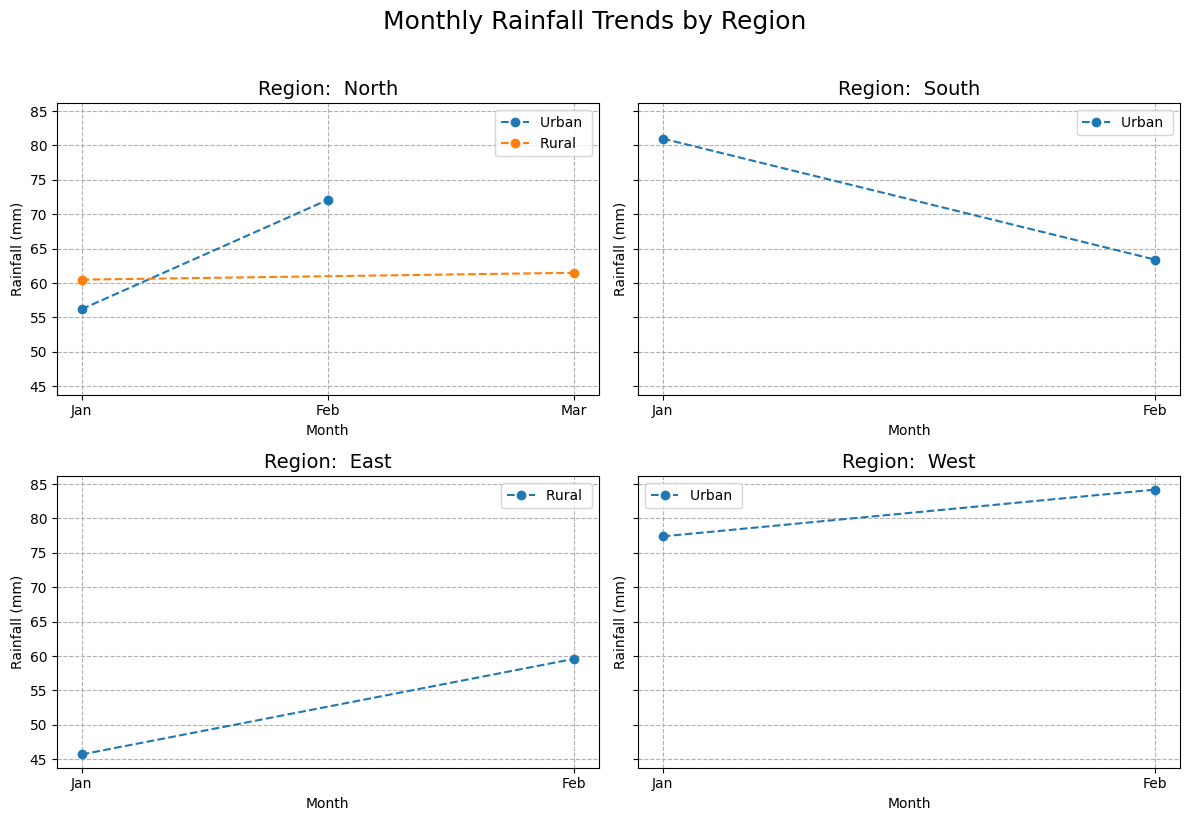

In [197]:
#Write your code here


month_order = ['Jan', 'Feb', 'Mar']
rainfall['Month'] = pd.Categorical(rainfall['Month'], categories=month_order, ordered=True)
rainfall = rainfall.sort_values('Month')

# Get unique regions to create a subplot for each
regions = rainfall['Region'].unique()

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    region_data = rainfall[rainfall['Region'] == region]
    
    for status in region_data['UrbanRural'].unique():
        status_data = region_data[region_data['UrbanRural'] == status]
        ax.plot(status_data['Month'], status_data['Rainfall_mm'], marker='o', linestyle='--', label=status)
        
    ax.set_title(f'Region: {region}', fontsize=14)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel('Rainfall (mm)', fontsize=10)
    ax.legend()
    ax.grid(True, linestyle='--')

# Overall title for the entire figure
fig.suptitle('Monthly Rainfall Trends by Region', fontsize=18, y=1.02)

# Adjust layout and hide any unused subplots
for i in range(len(regions), len(axes)):
    fig.delaxes(axes[i])
    
fig.tight_layout()

# Save the figure
plt.savefig('rainfall_trends_facet_grid_mpl.png')
plt.show()

3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here

- West Urban has the Highest Total Rainfall
- Urban Areas Receive More Rainfall
- East Region Has the lowest Rainfall
- West Shows Consistently High Monthly Rainfall
- South Experiences a Decline